In [133]:
import pandas as pd
import numpy as np
import sklearn.cluster as sc
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import skfuzzy as fuzz

In [134]:
data=pd.read_csv("Customer-Data - 2.csv")

In [135]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [136]:
X=data.dropna()
X=X.select_dtypes([np.number])

In [137]:
from sklearn.decomposition import PCA
p=PCA(n_components=2)
X=p.fit_transform(X)

In [138]:
k_means=sc.KMeans(n_clusters=3,random_state=42)

In [139]:
k_means.fit(X)
y_cmeans= k_means.predict(X)
print(k_means.cluster_centers_)

[[ 4835.28547935 -2056.00008813]
 [-2099.51305635   488.50291971]
 [19016.11661611  9412.20368972]]


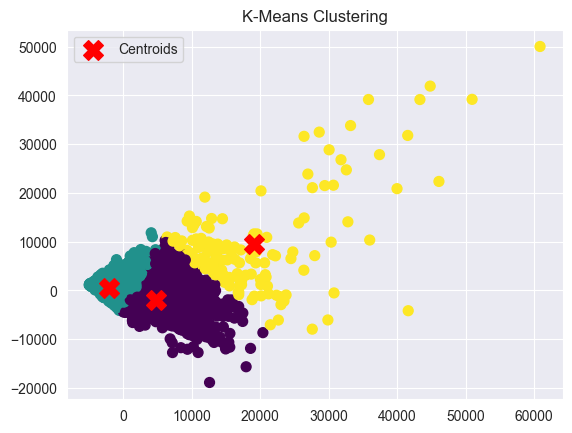

In [140]:
plt.scatter(X[:, 0], X[:, 1], c=y_cmeans, s=50, cmap='viridis') # Data points
plt.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids') # Centroids
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [141]:
db=sc.DBSCAN(eps=5,min_samples=15)
clusters=db.fit(X)
labels=db.labels_

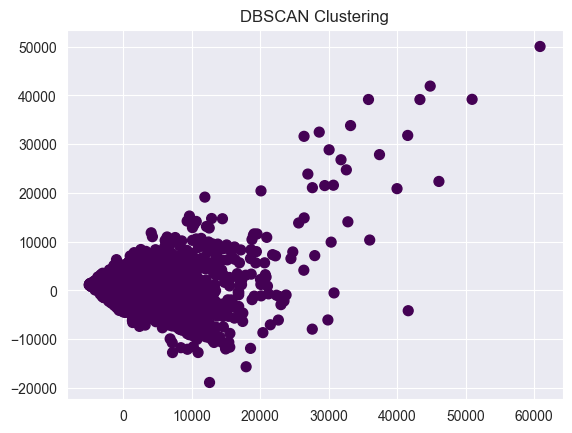

In [142]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis') # Data points
#plt.scatter(clusters[:, 0], clusters[:, 1],
            #s=200, c='red', marker='X', label='Centroids') # Centroids
plt.title("DBSCAN Clustering")
#plt.legend()
plt.show()

In [143]:

Z = linkage(X, method='ward')

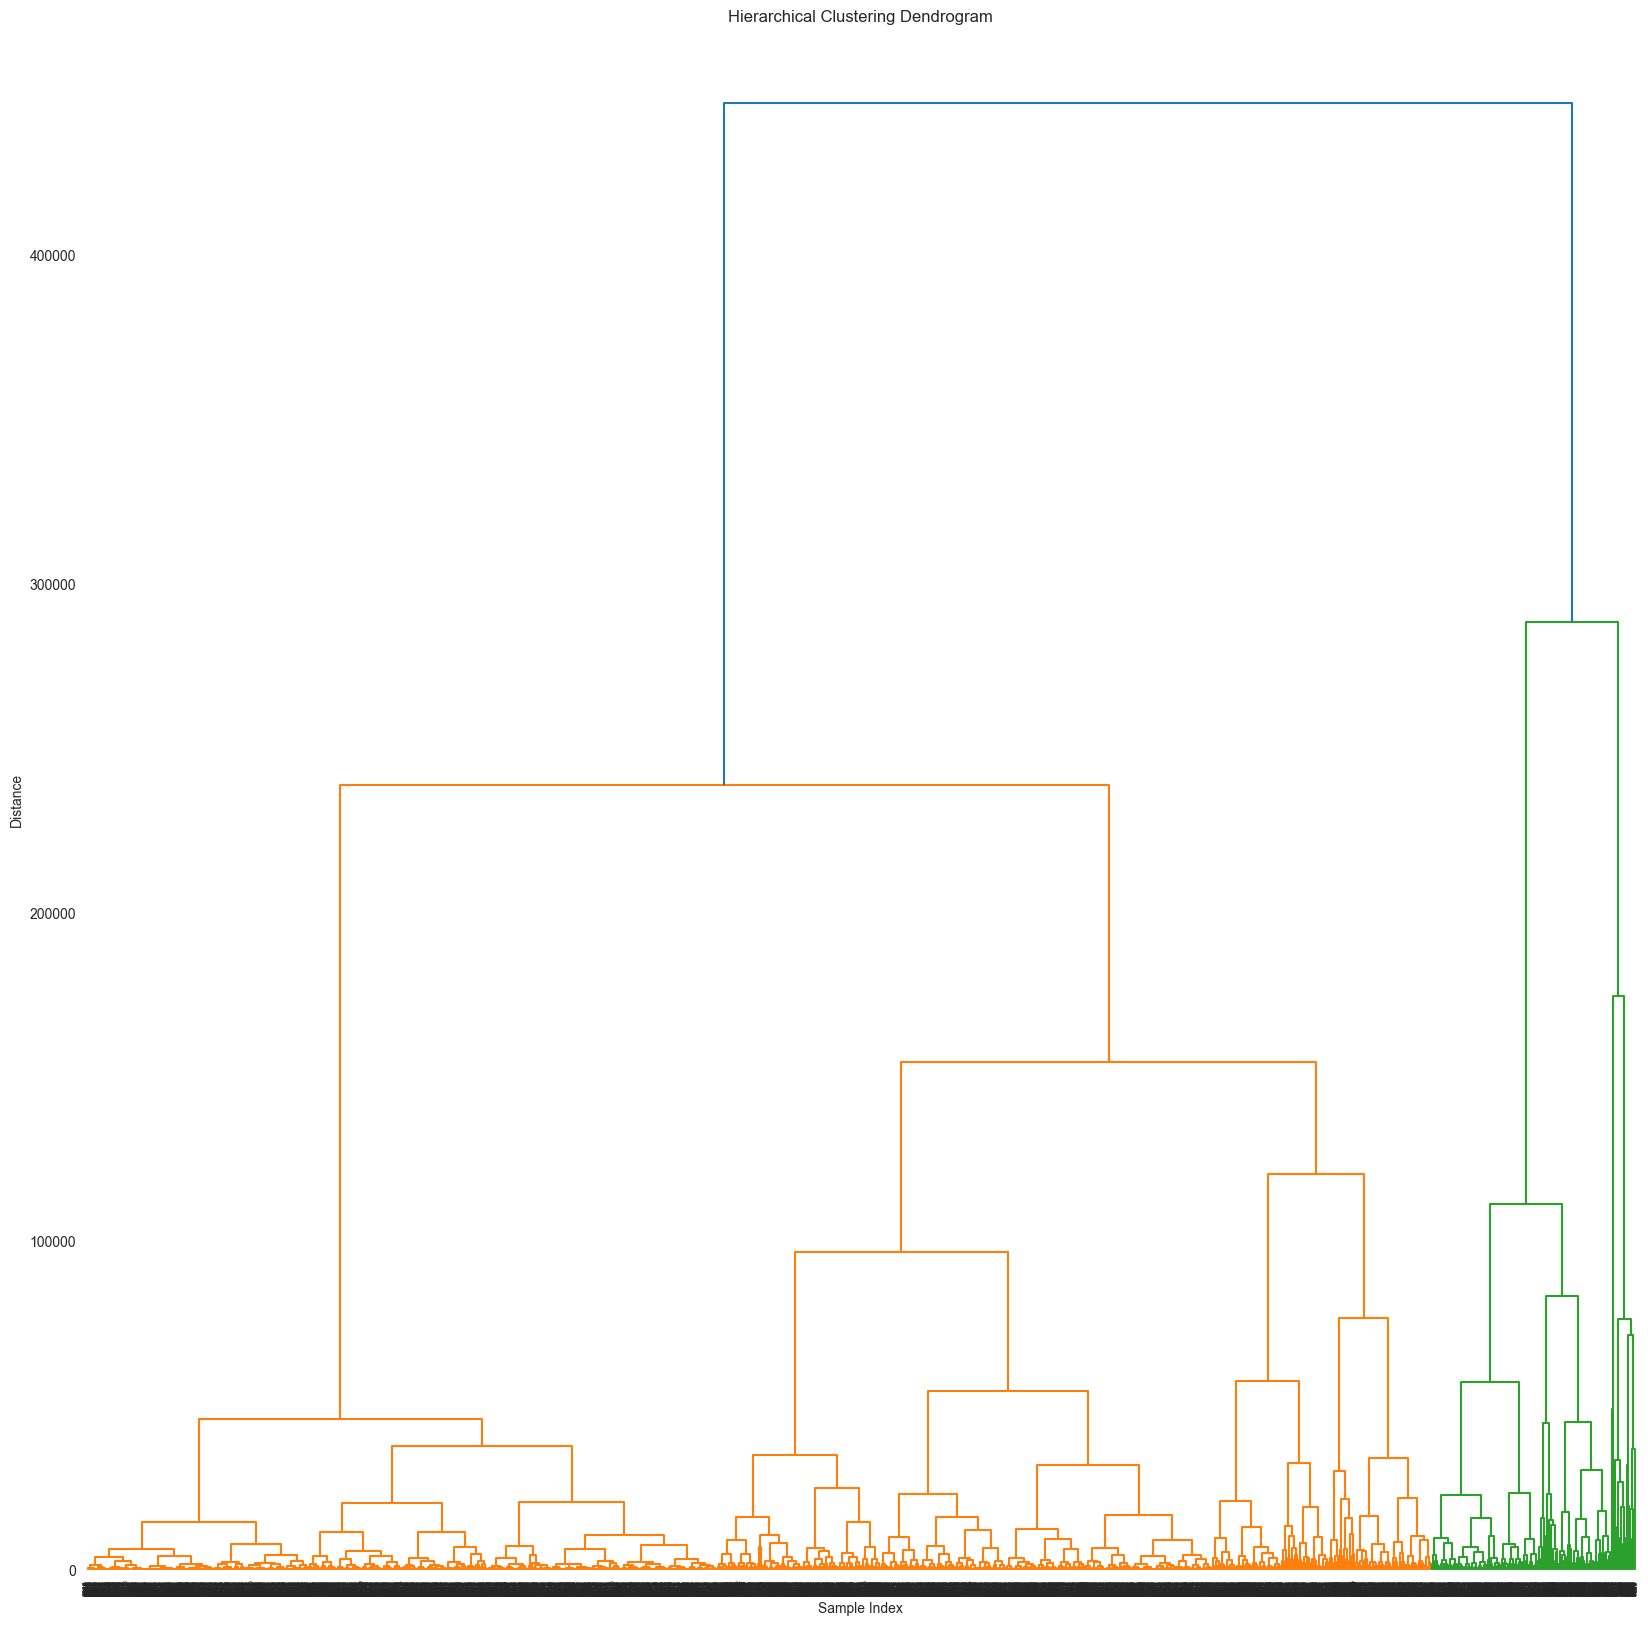

In [144]:


plt.figure(figsize=(20,20))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

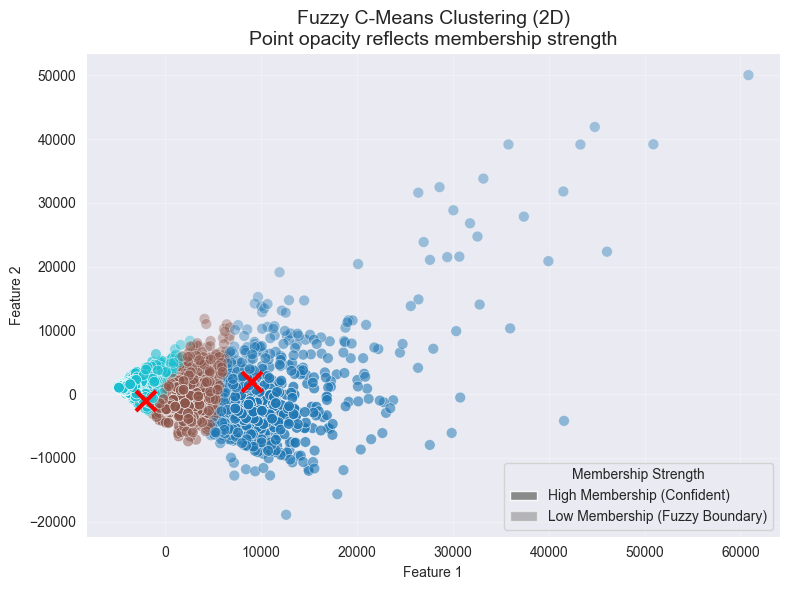

Fuzzy Partition Coefficient (FPC): 0.7443
FPC ranges from 0 to 1. Closer to 1 indicates better cluster separation.


In [145]:

c = 3          # Number of clusters
m = 2.0        # Fuzziness coefficient (typical range: 1.5 - 3.0)
error = 0.005  # Convergence threshold
maxiter = 1000 # Maximum iterations

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X.T, c=c, m=m, error=error, maxiter=maxiter, init=None
)

cluster_labels = np.argmax(u, axis=0)  # Cluster with highest membership
max_membership = np.max(u, axis=0)     # Confidence level (1.0 = certain)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X[:, 0], X[:, 1],
    c=cluster_labels, cmap='tab10',
    alpha=np.clip(max_membership, 0.3, 1.0), # Avoid fully transparent points
    edgecolor='w', linewidth=0.5, s=60
)

ax.plot(cntr[0, :], cntr[1, :], 'rx', markersize=15, markeredgewidth=3, label='Cluster Centers')

ax.set_title('Fuzzy C-Means Clustering (2D)\nPoint opacity reflects membership strength', fontsize=14)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=0.9, label='High Membership (Confident)'),
    Patch(facecolor='gray', alpha=0.5, label='Low Membership (Fuzzy Boundary)')
]
ax.legend(handles=legend_elements, loc='lower right', title='Membership Strength')

plt.tight_layout()
plt.show()

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print("FPC ranges from 0 to 1. Closer to 1 indicates better cluster separation.")